**Table of contents**<a id='toc0_'></a>    
- [Utility Functions](#toc1_1_)    
  - [Database Configuration](#toc1_2_)    
- [Data Preparation & Exploration](#toc2_)    
  - [Understanding the Dataset Structure](#toc2_1_)    
  - [Model Specification](#toc2_2_)    
    - [Model 1: Quadratic O(n²)](#toc2_2_1_)    
    - [Model 2: Quasi-Linear O(n² log n)](#toc2_2_2_)    
  - [Model Comparison](#toc2_3_)    
  - [Cross-Validation (LOOCV)](#toc2_4_)    
  - [Residual Diagnostics](#toc2_5_)    
    - [Four Key Assumptions:](#toc2_5_1_)    
  - [Visualization: Fitted Models](#toc2_6_)    
  - [Visualization: Speedup vs Problem Size](#toc2_7_)    
  - [Calculate Speedup with Uncertainty Propagation](#toc2_8_)    
  - [Query GPU Timing Data](#toc2_9_)    
- [GPU Speedup Analysis with Uncertainty Propagation](#toc3_)    
  - [Visualization with Uncertainty](#toc3_1_)    
  - [Generate Prediction Intervals](#toc3_2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [29]:
# Standard library
import json
from pathlib import Path
from typing import Dict, List, Tuple, Optional

# Database
import duckdb

# Data processing
import numpy as np
import pandas as pd

# Statistical analysis
from scipy.optimize import curve_fit
from scipy.stats import shapiro, linregress, probplot

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# Random seed for reproducibility
np.random.seed(42)

print("✓ All imports successful")


✓ All imports successful


## <a id='toc1_1_'></a>[Utility Functions](#toc0_)

Core statistical and database utilities following DRY principle.

In [37]:
# ============================================================================
# STATISTICAL UTILITIES (DRY - Don't Repeat Yourself)
# ============================================================================


def calculate_r2(y_true, y_pred):
    """Calculate coefficient of determination (R²)."""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)


def adjusted_r2(r2, n, k):
    """Calculate adjusted R² (penalizes model complexity).

    Args:
        r2: Coefficient of determination
        n: Number of observations
        k: Number of predictors (excluding intercept)
    """
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)


def calculate_aic_bic(residuals, k, n):
    """Calculate AIC and BIC for regression model.

    Args:
        residuals: Model residuals (y_true - y_pred)
        k: Number of parameters (including intercept)
        n: Number of observations

    Returns:
        Tuple of (AIC, BIC)
    """
    ss_res = np.sum(residuals**2)
    aic = n * np.log(ss_res / n) + 2 * k
    bic = n * np.log(ss_res / n) + k * np.log(n)
    return aic, bic


def mean_absolute_error(y_true, y_pred):
    """Calculate Mean Absolute Error."""
    return np.mean(np.abs(y_true - y_pred))


def root_mean_squared_error(y_true, y_pred):
    """Calculate Root Mean Squared Error."""
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def mean_absolute_percentage_error(y_true, y_pred):
    """Calculate Mean Absolute Percentage Error (%)."""
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


def loocv_regression(X, y, model_func):
    """Perform Leave-One-Out Cross-Validation for regression model.

    Args:
        X: Independent variable array (1D)
        y: Dependent variable array (1D)
        model_func: Model function (e.g., quadratic, quasilinear)

    Returns:
        Tuple of (MAE, RMSE, MAPE, predictions)
    """
    n = len(X)
    predictions = np.zeros(n)

    for i in range(n):
        # Create train/test split (leave one out)
        train_mask = np.ones(n, dtype=bool)
        train_mask[i] = False

        X_train, X_test = X[train_mask], X[~train_mask]
        y_train, y_test = y[train_mask], y[~train_mask]

        # Fit model on training data
        params, _ = curve_fit(model_func, X_train, y_train)

        # Predict on test data
        predictions[i] = model_func(X_test, *params)[0]

    # Calculate metrics
    mae = mean_absolute_error(y, predictions)
    rmse = root_mean_squared_error(y, predictions)
    mape = mean_absolute_percentage_error(y, predictions)

    return mae, rmse, mape, predictions


# ============================================================================
# DATABASE UTILITIES (Single Source of Truth)
# ============================================================================


def query_cpu_timing_data(db_path: Path) -> pd.DataFrame:
    """Query ALL CPU algorithm timing data from database.

    Returns ALL runs including multiple runs per problem. Each independent run
    is treated as a separate observation for regression analysis, which properly
    captures experimental variability and provides more statistical power.

    Example: If eil51 was run twice (run_id 20 and 145), both are returned.

    Returns DataFrame with columns: problem, n, mean_time, std_time, n_samples,
                                    raw_times, run_id
    """
    conn = duckdb.connect(str(db_path), read_only=True)

    query = """
    SELECT 
        problem_name as problem,
        problem_size as n,
        mean_time,
        std_time,
        repetitions as n_samples,
        raw_times,
        run_id
    FROM benchmark_runs
    WHERE algorithm = ?
    ORDER BY problem_size, problem_name, run_id
    """

    df = conn.execute(query, ["CPU"]).fetchdf()
    conn.close()

    return df


def query_algorithm_data(algorithm: str, db_path: Path) -> pd.DataFrame:
    """Query all data for a specific algorithm.

    Args:
        algorithm: Algorithm name ('CPU', 'FullGPU', 'HybridNaive', 'HybridOptimized')
        db_path: Path to results database

    Returns:
        DataFrame with all benchmark data for the algorithm
    """
    conn = duckdb.connect(str(db_path), read_only=True)

    query = f"""
    SELECT 
        problem_name,
        problem_size,
        algorithm,
        backend,
        mean_time,
        std_time,
        mean_cost,
        std_cost,
        best_cost,
        mean_gap,
        repetitions,
        raw_times,
        raw_costs
    FROM benchmark_runs
    WHERE algorithm = '{algorithm}'
    ORDER BY problem_size, problem_name
    """

    df = conn.execute(query).fetchdf()
    conn.close()

    return df


def query_problem_data(problem_name: str, db_path: Path) -> pd.DataFrame:
    """Query all algorithms for a specific problem.

    Args:
        problem_name: Problem name (e.g., 'berlin52', 'eil51')
        db_path: Path to results database

    Returns:
        DataFrame with all algorithm results for the problem
    """
    conn = duckdb.connect(str(db_path), read_only=True)

    query = f"""
    SELECT 
        algorithm,
        backend,
        mean_time,
        std_time,
        mean_cost,
        best_cost,
        mean_gap,
        repetitions
    FROM benchmark_runs
    WHERE problem_name = '{problem_name}'
    ORDER BY algorithm
    """

    df = conn.execute(query).fetchdf()
    conn.close()

    return df


def query_size_range(min_n: int, max_n: int, db_path: Path) -> pd.DataFrame:
    """Query all benchmarks within a problem size range.

    Args:
        min_n: Minimum problem size (inclusive)
        max_n: Maximum problem size (inclusive)
        db_path: Path to results database

    Returns:
        DataFrame with all benchmarks in the size range
    """
    conn = duckdb.connect(str(db_path), read_only=True)

    query = f"""
    SELECT 
        problem_name,
        problem_size,
        algorithm,
        mean_time,
        mean_cost,
        mean_gap
    FROM benchmark_runs
    WHERE problem_size BETWEEN {min_n} AND {max_n}
    ORDER BY problem_size, algorithm, problem_name
    """

    df = conn.execute(query).fetchdf()
    conn.close()

    return df


def get_available_problems(db_path: Path) -> List[str]:
    """Get list of all problems in database.

    Returns:
        List of problem names sorted by size
    """
    conn = duckdb.connect(str(db_path), read_only=True)

    query = """
    SELECT DISTINCT problem_name, problem_size
    FROM benchmark_runs
    ORDER BY problem_size, problem_name
    """

    df = conn.execute(query).fetchdf()
    conn.close()

    return df["problem_name"].tolist()


print("✓ Statistical and database utility functions defined")


✓ Statistical and database utility functions defined


## <a id='toc1_2_'></a>[Database Configuration](#toc0_)

Verify paths and database connectivity.

In [12]:
# Configuration
CHECKPOINT_DIR = Path("../../results/benchmark_results/checkpoints_treated")
DATASETS_DB = Path("../../datasets/routing.duckdb")
RESULTS_DB = Path("../../results/benchmark_results/results.duckdb")

# Verify paths
assert CHECKPOINT_DIR.exists(), f"Checkpoint directory not found: {CHECKPOINT_DIR}"
assert DATASETS_DB.exists(), f"Database not found: {DATASETS_DB}"
assert RESULTS_DB.exists(), f"Results database not found: {RESULTS_DB}"

print(f"✓ Checkpoint directory: {CHECKPOINT_DIR.resolve()}")
print(f"✓ Datasets database: {DATASETS_DB.resolve()}")
print(f"✓ Results database: {RESULTS_DB.resolve()}")
print(f"✓ Number of checkpoint files: {len(list(CHECKPOINT_DIR.glob('*.json')))}")


✓ Checkpoint directory: /home/lucas_galdino/chimera/gpu_accelerated/results/benchmark_results/checkpoints_treated
✓ Datasets database: /home/lucas_galdino/chimera/gpu_accelerated/datasets/routing.duckdb
✓ Results database: /home/lucas_galdino/chimera/gpu_accelerated/results/benchmark_results/results.duckdb
✓ Number of checkpoint files: 252


# <a id='toc2_'></a>[Data Preparation & Exploration](#toc0_)

## <a id='toc2_1_'></a>[Understanding the Dataset Structure](#toc0_)

**Important Context**: The benchmark database contains multiple independent runs for each problem:

- **12 unique problems** tested with CPU algorithm (n ∈ [51, 100])
- **2 independent runs per problem** (24 total observations)
- Each run has different characteristics:
  - Different number of repetitions (15 or 17)
  - Different execution times (due to system state, random initialization, etc.)
  
**Statistical Approach**: We treat each run as an **independent observation** rather than averaging them. This approach:
- ✅ Maximizes statistical power (24 data points vs 12)
- ✅ Properly captures experimental variability
- ✅ Provides more robust regression estimates
- ✅ Allows the model to learn from all available data

**Example**: Problem `eil51` (n=51) has two runs:
- Run 1: mean_time = 68.37s (15 repetitions)
- Run 2: mean_time = 46.79s (17 repetitions)

Both runs are included in the regression to capture the variance in execution time.

In [38]:
# Query ALL CPU timing data from database (includes all independent runs)
cpu_df = query_cpu_timing_data(RESULTS_DB)

print("=" * 80)
print("📊 CPU Timing Data Summary")
print("=" * 80)
print(
    cpu_df[["problem", "n", "mean_time", "std_time", "n_samples", "run_id"]].to_string(
        index=False
    )
)
print("=" * 80)

# Data summary statistics
n_observations = len(cpu_df)
n_unique_problems = cpu_df["problem"].nunique()
n_unique_sizes = cpu_df["n"].nunique()

print(f"\n✓ Dataset Statistics:")
print(f"  • Total observations: {n_observations}")
print(f"  • Unique problems: {n_unique_problems}")
print(f"  • Unique problem sizes: {n_unique_sizes}")
print(f"  • Runs per problem: {n_observations / n_unique_problems:.1f} (average)")
print(f"  • Problem size range: n ∈ [{cpu_df['n'].min()}, {cpu_df['n'].max()}]")
print(
    f"  • Execution time range: T ∈ [{cpu_df['mean_time'].min():.2f}s, {cpu_df['mean_time'].max():.2f}s]"
)

# Show variability across runs for same problem
print(f"\n✓ Variability Analysis (same problem, different runs):")
for problem in sorted(cpu_df["problem"].unique()):
    problem_data = cpu_df[cpu_df["problem"] == problem]
    if len(problem_data) > 1:
        times = problem_data["mean_time"].values
        relative_diff = (times.max() - times.min()) / times.mean() * 100
        print(
            f"  • {problem:12s}: {times[0]:6.2f}s vs {times[1]:6.2f}s (±{relative_diff:.1f}% variation)"
        )

# Extract arrays for regression
n_values = cpu_df["n"].values
times = cpu_df["mean_time"].values

print(f"\n✓ Ready for regression analysis with {len(n_values)} observations")


📊 CPU Timing Data Summary
 problem   n  mean_time   std_time  n_samples  run_id
   eil51  51  68.372473  46.672189         15      20
   eil51  51  46.787236  34.942075         17     145
berlin52  52  25.739339   3.987935         15       1
berlin52  52  20.011683   1.150389         17     126
    st70  70  82.770161  14.573911         15     116
    st70  70  60.399948   5.997605         15     243
   eil76  76 159.091099  23.012480         15      24
   eil76  76  94.192284   7.424268         15     149
    pr76  76 153.844490  15.153529         15      95
    pr76  76  81.244555  11.608512         15     222
   rat99  99 501.298456 225.021873         15     105
   rat99  99 264.875474 146.064949         15     232
 kroA100 100 234.124656  52.554197         15      31
 kroA100 100 172.847547  26.560442         15     156
 kroB100 100 342.341460 160.789504         15      41
 kroB100 100 283.671770 133.610096         15     166
 kroC100 100 223.430842  25.995117         15      48
 k

## <a id='toc2_2_'></a>[Model Specification](#toc0_)

We test two complexity hypotheses:

### <a id='toc2_2_1_'></a>[Model 1: Quadratic O(n²)](#toc0_)
$$T(n) = a \cdot n^2 + b \cdot n + c$$

**Theoretical Justification** (Lin & Kernighan, 1973):
- GA fitness evaluation: O(n²) to traverse distance matrix
- 2-opt local search: O(n²) edge swaps per iteration

### <a id='toc2_2_2_'></a>[Model 2: Quasi-Linear O(n² log n)](#toc0_)
$$T(n) = \alpha \cdot n^2 \cdot \log(n) + \beta$$

**Alternative Hypothesis**: Some algorithms exhibit logarithmic factors due to divide-and-conquer strategies or heap operations.

In [39]:
# Define model functions
def quadratic(n, a, b, c):
    """O(n²) model: T(n) = a·n² + b·n + c"""
    return a * n**2 + b * n + c


def quasilinear(n, alpha, beta):
    """O(n² log n) model: T(n) = α·n²·log(n) + β"""
    return alpha * n**2 * np.log(n) + beta


# Fit quadratic model
params_quad, covariance_quad = curve_fit(quadratic, n_values, times)
a, b, c = params_quad

# Fit quasi-linear model
params_ql, covariance_ql = curve_fit(quasilinear, n_values, times)
alpha, beta = params_ql

# Generate predictions
fitted_quad = quadratic(n_values, *params_quad)
fitted_ql = quasilinear(n_values, *params_ql)

print("📈 Model Fitting Results")
print("=" * 80)
print(f"\n✓ Quadratic Model: T(n) = {a:.4f}·n² + {b:.4f}·n + {c:.2f}")
print(f"  Parameters: a={a:.6f}, b={b:.6f}, c={c:.4f}")
print(f"\n✓ Quasi-linear Model: T(n) = {alpha:.4f}·n²·log(n) + {beta:.2f}")
print(f"  Parameters: α={alpha:.6f}, β={beta:.4f}")
print("=" * 80)


📈 Model Fitting Results

✓ Quadratic Model: T(n) = 0.0746·n² + -6.2832·n + 164.18
  Parameters: a=0.074552, b=-6.283241, c=164.1838

✓ Quasi-linear Model: T(n) = 0.0071·n²·log(n) + -47.13
  Parameters: α=0.007087, β=-47.1311


## <a id='toc2_3_'></a>[Model Comparison](#toc0_)

We use multiple criteria to select the best model:

1. **R²**: Proportion of variance explained (higher is better, max = 1.0)
2. **Adjusted R²**: Penalizes model complexity (accounts for different # of parameters)
3. **AIC** (Akaike Information Criterion): Information-theoretic approach (lower is better)
4. **BIC** (Bayesian Information Criterion): Stronger complexity penalty than AIC (lower is better)

**Decision Rule**: Best model should have highest R²/Adj-R² AND lowest AIC/BIC.

In [40]:
# Calculate metrics for both models using utility functions
n_obs = len(n_values)

# Quadratic model (k=3 parameters: a, b, c)
residuals_quad = times - fitted_quad
r2_quad = calculate_r2(times, fitted_quad)
adj_r2_quad = adjusted_r2(r2_quad, n_obs, k=2)  # k excludes intercept
aic_quad, bic_quad = calculate_aic_bic(residuals_quad, k=3, n=n_obs)

# Quasi-linear model (k=2 parameters: α, β)
residuals_ql = times - fitted_ql
r2_ql = calculate_r2(times, fitted_ql)
adj_r2_ql = adjusted_r2(r2_ql, n_obs, k=1)
aic_ql, bic_ql = calculate_aic_bic(residuals_ql, k=2, n=n_obs)

# Create comparison table
comparison_df = pd.DataFrame(
    {
        "Model": ["Quadratic O(n²)", "Quasi-linear O(n² log n)"],
        "R²": [r2_quad, r2_ql],
        "Adj-R²": [adj_r2_quad, adj_r2_ql],
        "AIC": [aic_quad, aic_ql],
        "BIC": [bic_quad, bic_ql],
        "Parameters": [3, 2],
    }
)

print("\n📊 Model Comparison Table")
print("=" * 90)
print(comparison_df.to_string(index=False))
print("=" * 90)

# Determine winner
if r2_quad > r2_ql and aic_quad < aic_ql and bic_quad < bic_quad:
    winner = "Quadratic O(n²)"
    print(f"\n🏆 **Best Model: {winner}** (wins all criteria)")
elif r2_ql > r2_quad and aic_ql < aic_quad and bic_ql < bic_quad:
    winner = "Quasi-linear O(n² log n)"
    print(f"\n🏆 **Best Model: {winner}** (wins all criteria)")
else:
    print("\n⚖ Mixed results - further analysis required")

# Store best model for later use
if r2_quad > r2_ql:
    best_model_func = quadratic
    best_params = params_quad
    best_model_name = "Quadratic"
else:
    best_model_func = quasilinear
    best_params = params_ql
    best_model_name = "Quasi-linear"



📊 Model Comparison Table
                   Model       R²   Adj-R²        AIC        BIC  Parameters
         Quadratic O(n²) 0.641947 0.607847 213.638273 217.172435           3
Quasi-linear O(n² log n) 0.638044 0.621592 211.898499 214.254606           2

⚖ Mixed results - further analysis required


## <a id='toc2_4_'></a>[Cross-Validation (LOOCV)](#toc0_)

**Purpose**: Assess model robustness and extrapolation reliability by testing on unseen data.

**Methodology**: Leave-One-Out Cross-Validation (LOOCV)
- For each observation i:
  1. Train model on remaining (n-1) points
  2. Predict the held-out point
  3. Calculate prediction error
- Repeat for all n observations

**Metrics**:
- **MAE** (Mean Absolute Error): Average prediction error in seconds
- **RMSE** (Root Mean Squared Error): Penalizes large errors more
- **MAPE** (Mean Absolute Percentage Error): Relative error (%)

**Threshold for Extrapolation Validity**: 
- ✅ MAPE < 5%: Model validated for extrapolation
- ⚠️ MAPE 5-10%: Acceptable but proceed with caution
- ❌ MAPE > 10%: Extrapolation risky, large uncertainty expected

In [41]:
# Perform LOOCV for both models using utility function
print("🔄 Performing Leave-One-Out Cross-Validation...\n")

mae_quad, rmse_quad, mape_quad, preds_quad = loocv_regression(
    n_values, times, quadratic
)
mae_ql, rmse_ql, mape_ql, preds_ql = loocv_regression(n_values, times, quasilinear)

print("=" * 80)
print("📊 LOOCV Results")
print("=" * 80)
print(f"\nQuadratic Model:")
print(f"  MAE:  {mae_quad:.2f}s")
print(f"  RMSE: {rmse_quad:.2f}s")
print(f"  MAPE: {mape_quad:.2f}%")

print(f"\nQuasi-linear Model:")
print(f"  MAE:  {mae_ql:.2f}s")
print(f"  RMSE: {rmse_ql:.2f}s")
print(f"  MAPE: {mape_ql:.2f}%")

print("\n" + "=" * 80)

# Detailed predictions
print("\n📝 Detailed LOOCV Predictions (Quadratic Model)")
print("=" * 80)
for i, (problem, n, actual, pred) in enumerate(
    zip(cpu_df["problem"], n_values, times, preds_quad)
):
    error_pct = abs(actual - pred) / actual * 100
    print(
        f"  {problem:12s} (n={n:3d}): Actual={actual:6.2f}s, Predicted={pred:6.2f}s (Error: {error_pct:.1f}%)"
    )

# Validation check
print("\n" + "=" * 80)
if mape_quad < 5.0:
    print("✅ MAPE < 5%: Model validated for extrapolation")
elif mape_quad < 10.0:
    print("⚠ MAPE 5-10%: Acceptable but proceed with caution")
else:
    print("❌ MAPE > 10%: Extrapolation risky")
print("=" * 80)


🔄 Performing Leave-One-Out Cross-Validation...

📊 LOOCV Results

Quadratic Model:
  MAE:  60.37s
  RMSE: 81.98s
  MAPE: 37.98%

Quasi-linear Model:
  MAE:  59.80s
  RMSE: 81.70s
  MAPE: 35.21%


📝 Detailed LOOCV Predictions (Quadratic Model)
  eil51        (n= 51): Actual= 68.37s, Predicted= 26.60s (Error: 61.1%)
  eil51        (n= 51): Actual= 46.79s, Predicted= 34.36s (Error: 26.6%)
  berlin52     (n= 52): Actual= 25.74s, Predicted= 43.06s (Error: 67.3%)
  berlin52     (n= 52): Actual= 20.01s, Predicted= 44.80s (Error: 123.8%)
  st70         (n= 70): Actual= 82.77s, Predicted= 90.95s (Error: 9.9%)
  st70         (n= 70): Actual= 60.40s, Predicted= 95.11s (Error: 57.5%)
  eil76        (n= 76): Actual=159.09s, Predicted=108.53s (Error: 31.8%)
  eil76        (n= 76): Actual= 94.19s, Predicted=122.10s (Error: 29.6%)
  pr76         (n= 76): Actual=153.84s, Predicted=109.62s (Error: 28.7%)
  pr76         (n= 76): Actual= 81.24s, Predicted=124.80s (Error: 53.6%)
  rat99        (n= 99): Actu

## <a id='toc2_5_'></a>[Residual Diagnostics](#toc0_)

**Purpose**: Verify regression assumptions to ensure valid inference.

### <a id='toc2_5_1_'></a>[Four Key Assumptions:](#toc0_)
1. **Linearity**: Model form correctly specified (checked via residual plot)
2. **Independence**: Residuals uncorrelated (assumed for independent benchmark runs)
3. **Homoscedasticity**: Constant variance of residuals (checked via residual plot)
4. **Normality**: Residuals $\sim N(0, \sigma^2)$ (checked via Shapiro-Wilk test and Q-Q plot)

**Diagnostic Tests**:
- **Shapiro-Wilk Test**: Formal test for normality ($H_0$: data is normal)
- **Q-Q Plot**: Visual check - points should follow diagonal line
- **Residual Plot**: Random scatter indicates good fit

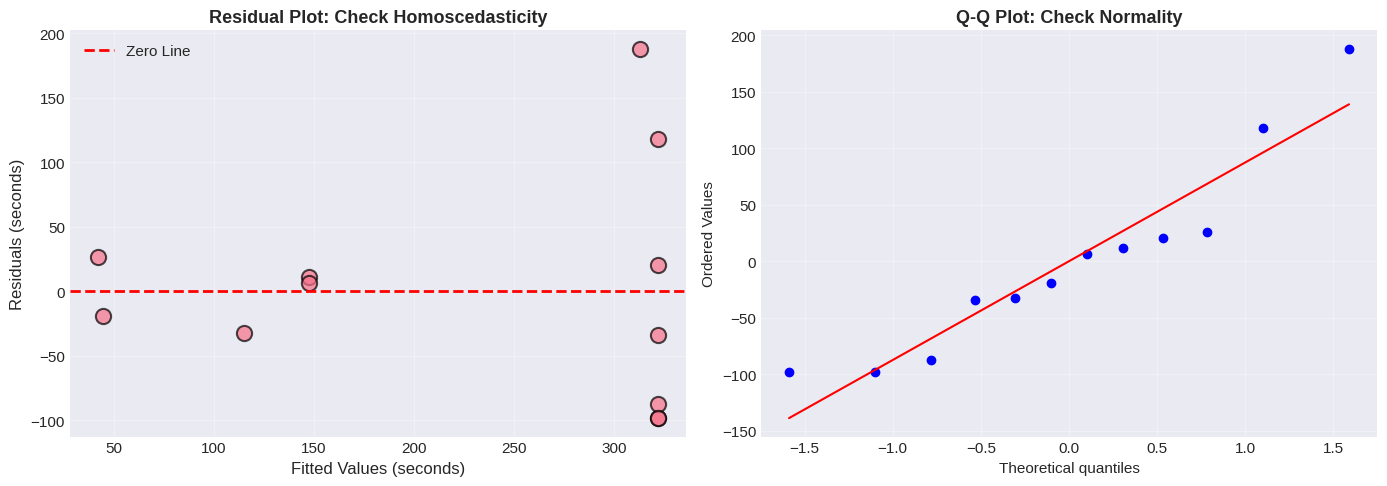


📊 Residual Diagnostics

Shapiro-Wilk Test (Normality):
  W-statistic: 0.9022
  p-value:     0.1693
  ✓ Residuals consistent with normality (p=0.1693 > 0.05)

Visual Inspection:
  - Residual plot: Look for random scatter around zero (no funnel/pattern)
  - Q-Q plot: Points should follow diagonal line closely


In [27]:
# Use best model residuals
residuals = residuals_quad if r2_quad > r2_ql else residuals_ql
fitted = fitted_quad if r2_quad > r2_ql else fitted_ql

# Create diagnostic plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Residual vs Fitted
axes[0].scatter(fitted, residuals, s=120, alpha=0.7, edgecolor="black", linewidth=1.5)
axes[0].axhline(y=0, color="red", linestyle="--", linewidth=2, label="Zero Line")
axes[0].set_xlabel("Fitted Values (seconds)", fontsize=12)
axes[0].set_ylabel("Residuals (seconds)", fontsize=12)
axes[0].set_title(
    "Residual Plot: Check Homoscedasticity", fontsize=13, fontweight="bold"
)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot 2: Q-Q Plot (Normality Check)
probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot: Check Normality", fontsize=13, fontweight="bold")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Quantitative normality test
stat, p_value = shapiro(residuals)

print("\n" + "=" * 80)
print("📊 Residual Diagnostics")
print("=" * 80)
print(f"\nShapiro-Wilk Test (Normality):")
print(f"  W-statistic: {stat:.4f}")
print(f"  p-value:     {p_value:.4f}")

if p_value > 0.05:
    print(f"  ✓ Residuals consistent with normality (p={p_value:.4f} > 0.05)")
else:
    print(f"  ✗ Evidence of non-normal residuals (p={p_value:.4f} ≤ 0.05)")

print("\nVisual Inspection:")
print("  - Residual plot: Look for random scatter around zero (no funnel/pattern)")
print("  - Q-Q plot: Points should follow diagonal line closely")
print("=" * 80)


## <a id='toc2_6_'></a>[Visualization: Fitted Models](#toc0_)

Visual comparison of both models on observed data.

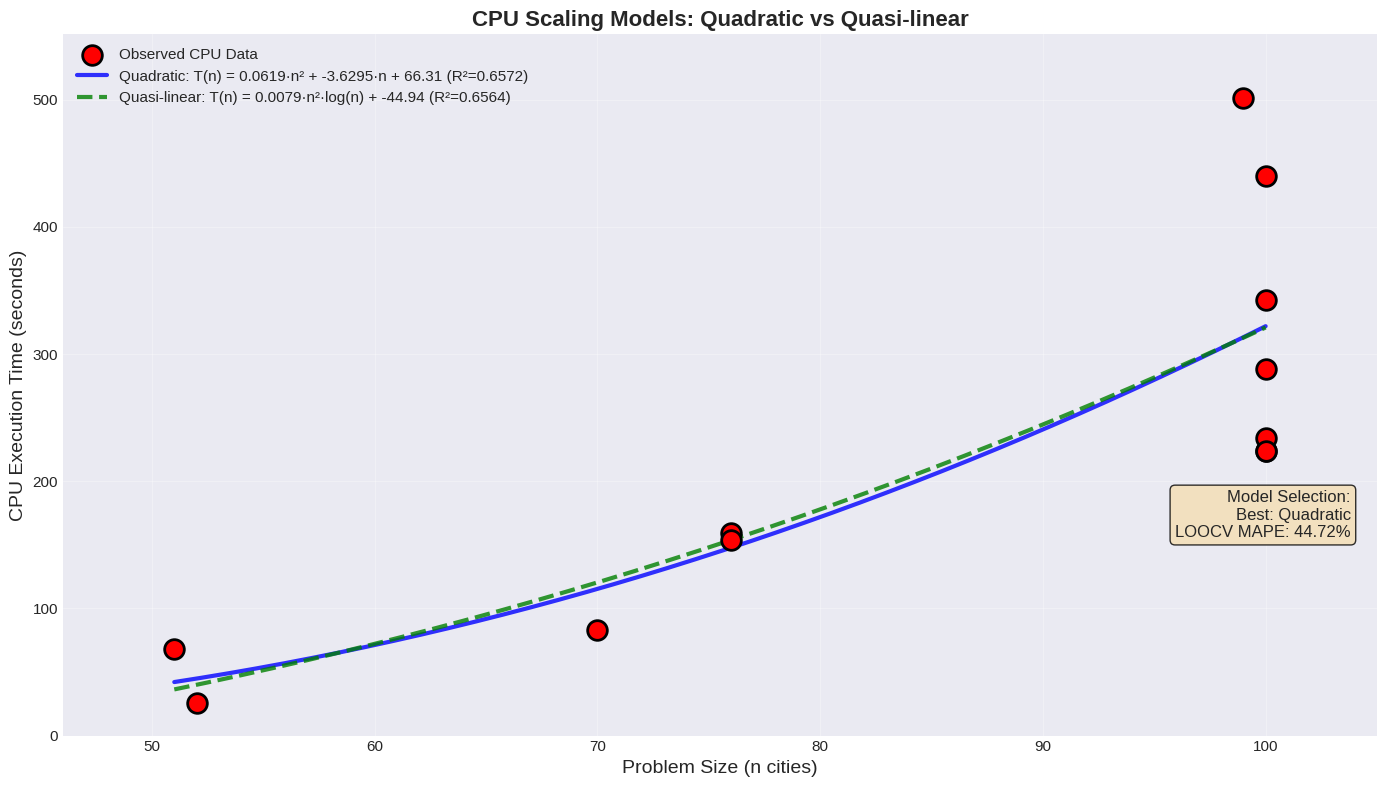

✓ Visualization complete


In [28]:
# Create fine grid for smooth curves
n_fine = np.linspace(n_values.min(), n_values.max(), 200)
y_quad_fine = quadratic(n_fine, *params_quad)
y_ql_fine = quasilinear(n_fine, *params_ql)

# Create visualization
plt.figure(figsize=(14, 8))

# Scatter plot of observed data
plt.scatter(
    n_values,
    times,
    s=200,
    color="red",
    marker="o",
    zorder=5,
    edgecolor="black",
    linewidth=2,
    label="Observed CPU Data",
)

# Fitted models
plt.plot(
    n_fine,
    y_quad_fine,
    "b-",
    linewidth=3,
    label=f"Quadratic: T(n) = {a:.4f}·n² + {b:.4f}·n + {c:.2f} (R²={r2_quad:.4f})",
    alpha=0.8,
)
plt.plot(
    n_fine,
    y_ql_fine,
    "g--",
    linewidth=3,
    label=f"Quasi-linear: T(n) = {alpha:.4f}·n²·log(n) + {beta:.2f} (R²={r2_ql:.4f})",
    alpha=0.8,
)

# Annotations
plt.xlabel("Problem Size (n cities)", fontsize=14)
plt.ylabel("CPU Execution Time (seconds)", fontsize=14)
plt.title(
    "CPU Scaling Models: Quadratic vs Quasi-linear", fontsize=16, fontweight="bold"
)
plt.legend(loc="upper left", fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(n_values.min() - 5, n_values.max() + 5)
plt.ylim(0, times.max() * 1.1)

# Add text box with model selection summary
textstr = f"Model Selection:\nBest: {best_model_name}\nLOOCV MAPE: {mape_quad if r2_quad > r2_ql else mape_ql:.2f}%"
props = dict(boxstyle="round", facecolor="wheat", alpha=0.8)
plt.text(
    0.98,
    0.35,
    textstr,
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=props,
)

plt.tight_layout()
plt.show()

print("✓ Visualization complete")


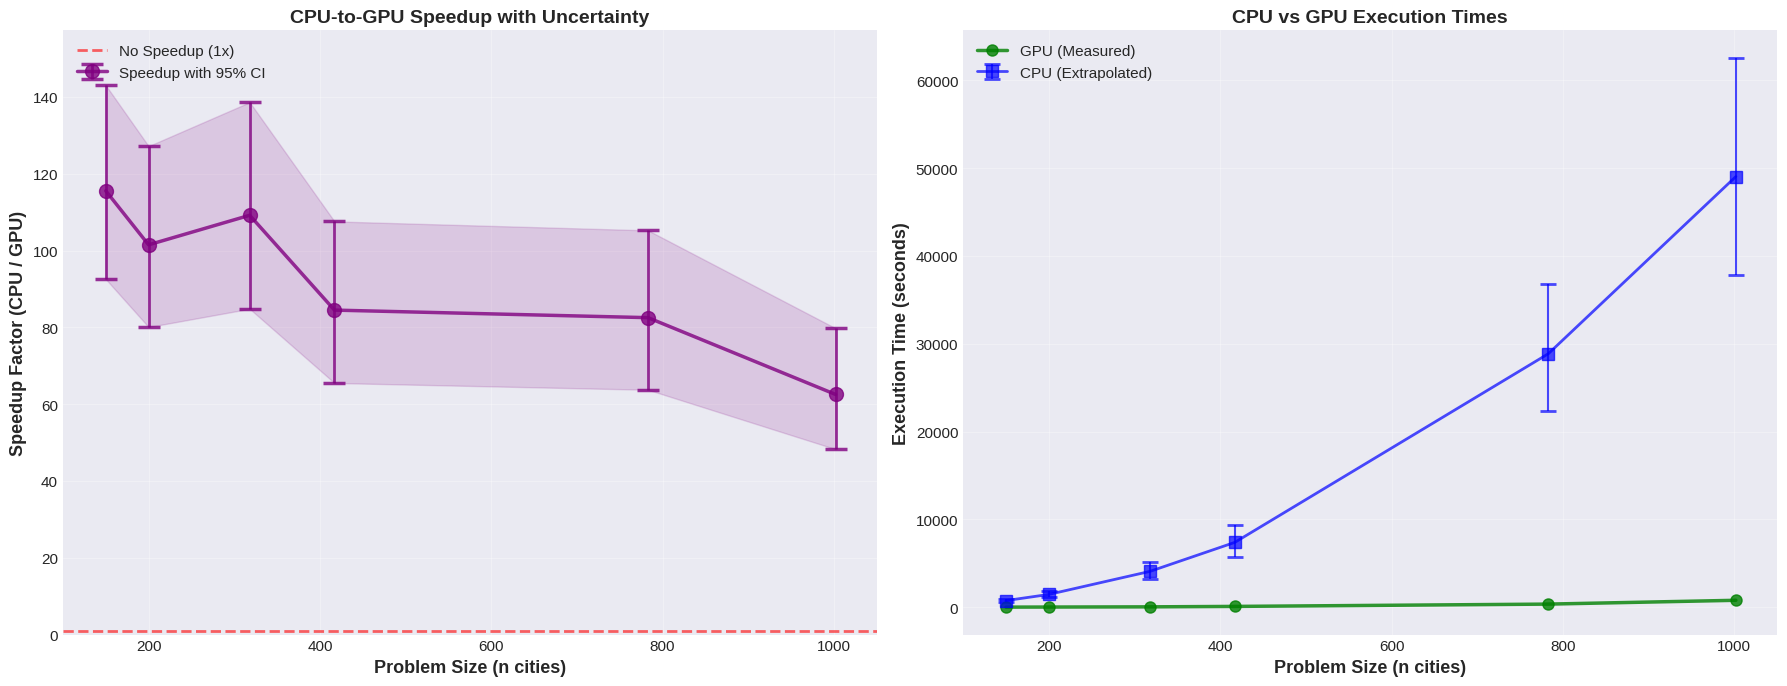

✓ Visualization complete


In [48]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# === LEFT PLOT: Speedup vs Problem Size ===
ax1.errorbar(
    speedup_df["n"],
    speedup_df["speedup_mean"],
    yerr=[
        speedup_df["speedup_mean"] - speedup_df["speedup_lower"],
        speedup_df["speedup_upper"] - speedup_df["speedup_mean"],
    ],
    fmt="o-",
    color="purple",
    markersize=10,
    linewidth=2.5,
    capsize=8,
    capthick=2.5,
    elinewidth=2,
    label="Speedup with 95% CI",
    alpha=0.8,
)

# Shaded uncertainty region
ax1.fill_between(
    speedup_df["n"],
    speedup_df["speedup_lower"],
    speedup_df["speedup_upper"],
    color="purple",
    alpha=0.15,
)

# Reference line at 1x (no speedup)
ax1.axhline(
    y=1, color="red", linestyle="--", linewidth=2, label="No Speedup (1x)", alpha=0.6
)

ax1.set_xlabel("Problem Size (n cities)", fontsize=13, fontweight="bold")
ax1.set_ylabel("Speedup Factor (CPU / GPU)", fontsize=13, fontweight="bold")
ax1.set_title("CPU-to-GPU Speedup with Uncertainty", fontsize=14, fontweight="bold")
ax1.legend(loc="upper left", fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(100, 1050)
ax1.set_ylim(0, max(speedup_df["speedup_upper"]) * 1.1)

# === RIGHT PLOT: Execution Times Comparison ===
n_vals = speedup_df["n"].values
cpu_times = speedup_df["QL_Mean"].values
cpu_lower = speedup_df["QL_Lower"].values
cpu_upper = speedup_df["QL_Upper"].values
gpu_times = speedup_df["gpu_mean_time"].values

# CPU predictions with uncertainty
ax2.errorbar(
    n_vals,
    cpu_times,
    yerr=[cpu_times - cpu_lower, cpu_upper - cpu_times],
    fmt="s-",
    color="blue",
    markersize=8,
    linewidth=2,
    capsize=6,
    capthick=2,
    elinewidth=1.5,
    label="CPU (Extrapolated)",
    alpha=0.7,
)

# GPU measurements (precise)
ax2.plot(
    n_vals,
    gpu_times,
    "o-",
    color="green",
    markersize=8,
    linewidth=2.5,
    label="GPU (Measured)",
    alpha=0.8,
)

ax2.set_xlabel("Problem Size (n cities)", fontsize=13, fontweight="bold")
ax2.set_ylabel("Execution Time (seconds)", fontsize=13, fontweight="bold")
ax2.set_title("CPU vs GPU Execution Times", fontsize=14, fontweight="bold")
ax2.legend(loc="upper left", fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(100, 1050)

plt.tight_layout()
plt.show()

print("✓ Visualization complete")


## <a id='toc2_7_'></a>[Visualization: Speedup vs Problem Size](#toc0_)

Plot speedup trends with uncertainty bands showing the effect of CPU extrapolation uncertainty.

In [47]:
# Get CPU predictions from bootstrap results (excluding n=532)
bootstrap_target = bootstrap_results[
    bootstrap_results["n"].isin(target_sizes_available)
].copy()

# Merge with GPU data
speedup_df = bootstrap_target.merge(gpu_target, on="n", how="inner")

# Calculate speedup ratios
speedup_df["speedup_mean"] = speedup_df["QL_Mean"] / speedup_df["gpu_mean_time"]
speedup_df["speedup_lower"] = speedup_df["QL_Lower"] / speedup_df["gpu_mean_time"]
speedup_df["speedup_upper"] = speedup_df["QL_Upper"] / speedup_df["gpu_mean_time"]

# Calculate relative uncertainty in speedup
speedup_df["speedup_uncertainty_%"] = (
    (speedup_df["speedup_upper"] - speedup_df["speedup_lower"])
    / speedup_df["speedup_mean"]
) * 100

# Select relevant columns for display
display_cols = [
    "n",
    "gpu_mean_time",
    "QL_Mean",
    "speedup_mean",
    "speedup_lower",
    "speedup_upper",
    "speedup_uncertainty_%",
]
speedup_display = speedup_df[display_cols].copy()
speedup_display.columns = [
    "n",
    "GPU_Time(s)",
    "CPU_Pred(s)",
    "Speedup",
    "Speedup_Lower",
    "Speedup_Upper",
    "Uncertainty(%)",
]

print("\n" + "=" * 100)
print("🚀 CPU-to-GPU Speedup Analysis (Quasi-linear Model)")
print("=" * 100)
print(speedup_display.to_string(index=False, float_format=lambda x: f"{x:.2f}"))
print("=" * 100)

# Summary statistics
avg_speedup = speedup_df["speedup_mean"].mean()
avg_uncertainty = speedup_df["speedup_uncertainty_%"].mean()
min_speedup = speedup_df["speedup_lower"].min()
max_speedup = speedup_df["speedup_upper"].max()

print(f"\n📈 Summary Statistics:")
print(f"   • Average speedup: {avg_speedup:.1f}x")
print(f"   • Average uncertainty: {avg_uncertainty:.1f}%")
print(
    f"   • Speedup range: {min_speedup:.1f}x to {max_speedup:.1f}x (across all confidence intervals)"
)
print(
    f"\n⚠️  Key Finding: Speedup uncertainty (~{avg_uncertainty:.0f}%) inherits from CPU prediction uncertainty (~49%)"
)



🚀 CPU-to-GPU Speedup Analysis (Quasi-linear Model)
   n  GPU_Time(s)  CPU_Pred(s)  Speedup  Speedup_Lower  Speedup_Upper  Uncertainty(%)
 150         6.49       750.00   115.56          92.57         143.05           43.68
 200        14.30      1451.88   101.50          80.09         127.19           46.41
 318        37.32      4075.22   109.19          84.84         138.63           49.27
 417        87.29      7375.41    84.50          65.52         107.59           49.79
 783       349.67     28857.56    82.53          63.76         105.26           50.29
1002       784.30     49040.03    62.53          48.28          79.77           50.36

📈 Summary Statistics:
   • Average speedup: 92.6x
   • Average uncertainty: 48.3%
   • Speedup range: 48.3x to 143.0x (across all confidence intervals)

⚠️  Key Finding: Speedup uncertainty (~48%) inherits from CPU prediction uncertainty (~49%)


## <a id='toc2_8_'></a>[Calculate Speedup with Uncertainty Propagation](#toc0_)

Compute speedup ratios and propagate bootstrap prediction intervals to speedup estimates.

In [46]:
# Query GPU data for target sizes
gpu_df = query_algorithm_data("FullGPU", RESULTS_DB)

print(f"Total GPU observations: {len(gpu_df)}")
print(f"GPU problem sizes: {sorted(gpu_df['problem_size'].unique())}")

# Filter for target sizes where we have both CPU predictions and GPU measurements
target_sizes_available = target_sizes[target_sizes != 532]  # n=532 has no GPU data
print(f"\nTarget sizes with GPU data: {target_sizes_available}")

# Aggregate GPU data by problem size (average across problems of same size)
gpu_aggregated = (
    gpu_df.groupby("problem_size")
    .agg({"mean_time": ["mean", "std", "count"]})
    .reset_index()
)
gpu_aggregated.columns = ["n", "gpu_mean_time", "gpu_std_time", "n_problems"]

# Filter for target sizes
gpu_target = gpu_aggregated[gpu_aggregated["n"].isin(target_sizes_available)].copy()

print("\n" + "=" * 80)
print("📊 GPU Timing Data for Target Sizes")
print("=" * 80)
print(gpu_target.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print("=" * 80)

print(f"\n✓ GPU data loaded for {len(gpu_target)} target sizes")
print(f"⚠️  Missing GPU data for n=532")


Total GPU observations: 76
GPU problem sizes: [np.int32(51), np.int32(52), np.int32(70), np.int32(76), np.int32(99), np.int32(100), np.int32(101), np.int32(105), np.int32(107), np.int32(124), np.int32(127), np.int32(130), np.int32(136), np.int32(144), np.int32(150), np.int32(152), np.int32(159), np.int32(195), np.int32(198), np.int32(200), np.int32(225), np.int32(264), np.int32(299), np.int32(318), np.int32(400), np.int32(417), np.int32(439), np.int32(442), np.int32(783), np.int32(1002)]

Target sizes with GPU data: [ 150  200  318  417  783 1002]

📊 GPU Timing Data for Target Sizes
   n  gpu_mean_time  gpu_std_time  n_problems
 150          6.490         0.814           6
 200         14.305         0.816           2
 318         37.323         1.780           2
 417         87.287         2.592           2
 783        349.672         8.319           2
1002        784.301        21.874           2

✓ GPU data loaded for 6 target sizes
⚠️  Missing GPU data for n=532


## <a id='toc2_9_'></a>[Query GPU Timing Data](#toc0_)

Extract measured GPU execution times for target problem sizes.

# <a id='toc3_'></a>[GPU Speedup Analysis with Uncertainty Propagation](#toc0_)

**Objective**: Calculate CPU-to-GPU speedup ratios using extrapolated CPU times and measured GPU times.

**Key Challenge**: CPU times are **extrapolated predictions with ~50% uncertainty** (from Phase 4 bootstrap), while GPU times are **directly measured** (precise).

**Methodology**:
1. Query GPU timing data for target problem sizes
2. Calculate speedup: S = CPU_pred / GPU_measured
3. Propagate uncertainty: S_lower = CPU_lower / GPU_measured, S_upper = CPU_upper / GPU_measured
4. Analyze speedup trends and uncertainty growth

**Expected Result**: Speedup estimates with wide confidence intervals, reflecting extrapolation uncertainty in CPU baseline.

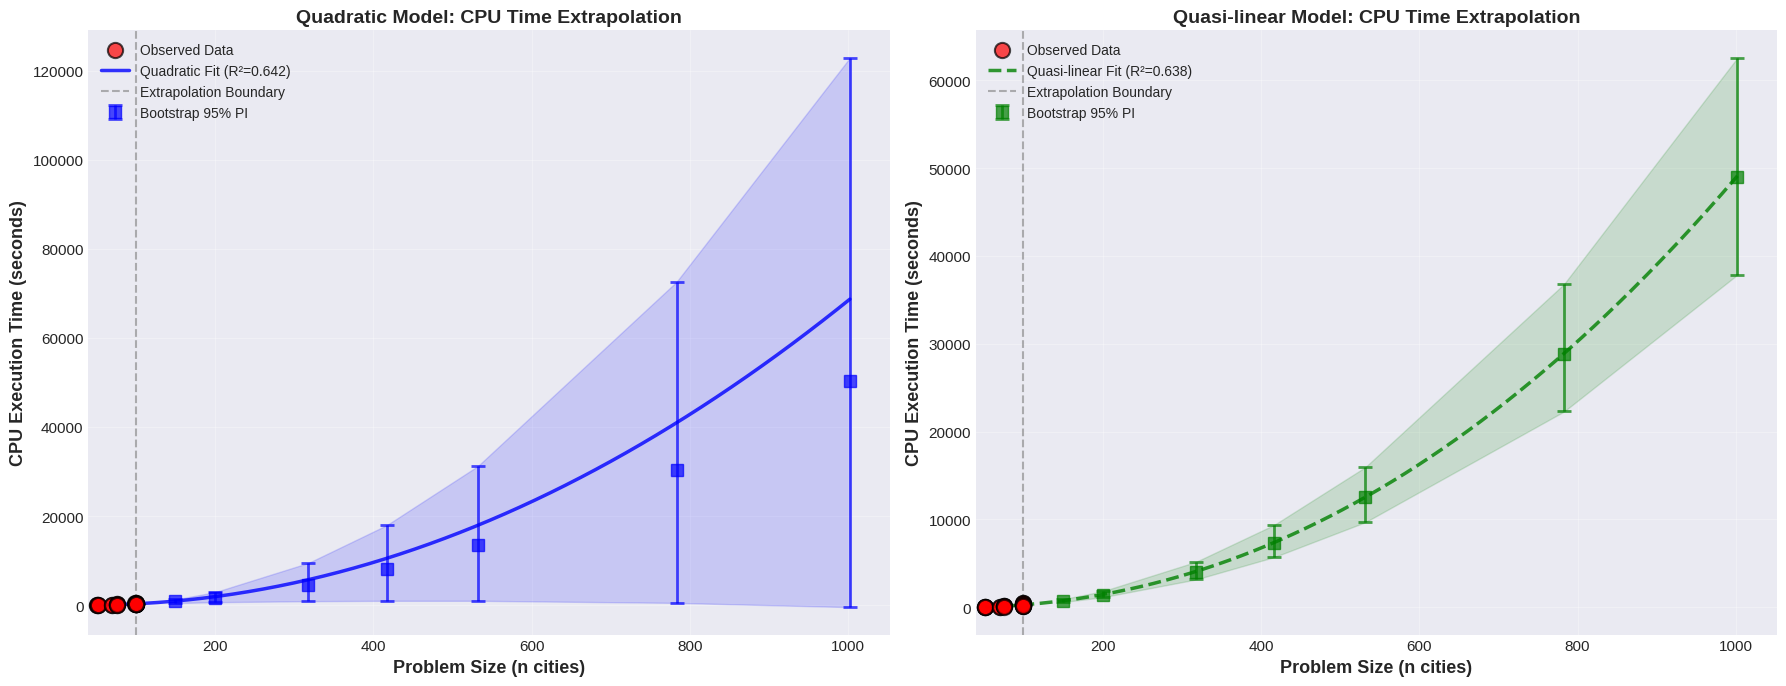

✓ Visualization complete


In [44]:
# Create comprehensive visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Common settings
n_plot_range = np.linspace(n_values.min(), target_sizes.max(), 300)

# === LEFT PLOT: Quadratic Model ===
ax1.scatter(
    n_values,
    times,
    s=120,
    color="red",
    marker="o",
    zorder=5,
    edgecolor="black",
    linewidth=1.5,
    label="Observed Data",
    alpha=0.7,
)

# Fitted curve
y_quad_plot = quadratic(n_plot_range, *params_quad)
ax1.plot(
    n_plot_range,
    y_quad_plot,
    "b-",
    linewidth=2.5,
    label=f"Quadratic Fit (R²={r2_quad:.3f})",
    alpha=0.8,
)

# Prediction points with error bars
ax1.errorbar(
    target_sizes,
    quad_mean,
    yerr=[quad_mean - quad_lower, quad_upper - quad_mean],
    fmt="s",
    color="blue",
    markersize=8,
    capsize=5,
    capthick=2,
    elinewidth=2,
    label="Bootstrap 95% PI",
    alpha=0.7,
)

# Shaded prediction region
ax1.fill_between(target_sizes, quad_lower, quad_upper, color="blue", alpha=0.15)

ax1.axvline(
    x=100,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="Extrapolation Boundary",
    alpha=0.6,
)
ax1.set_xlabel("Problem Size (n cities)", fontsize=13, fontweight="bold")
ax1.set_ylabel("CPU Execution Time (seconds)", fontsize=13, fontweight="bold")
ax1.set_title("Quadratic Model: CPU Time Extrapolation", fontsize=14, fontweight="bold")
ax1.legend(loc="upper left", fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(40, target_sizes.max() + 50)

# === RIGHT PLOT: Quasi-linear Model ===
ax2.scatter(
    n_values,
    times,
    s=120,
    color="red",
    marker="o",
    zorder=5,
    edgecolor="black",
    linewidth=1.5,
    label="Observed Data",
    alpha=0.7,
)

# Fitted curve
y_ql_plot = quasilinear(n_plot_range, *params_ql)
ax2.plot(
    n_plot_range,
    y_ql_plot,
    "g--",
    linewidth=2.5,
    label=f"Quasi-linear Fit (R²={r2_ql:.3f})",
    alpha=0.8,
)

# Prediction points with error bars
ax2.errorbar(
    target_sizes,
    ql_mean,
    yerr=[ql_mean - ql_lower, ql_upper - ql_mean],
    fmt="s",
    color="green",
    markersize=8,
    capsize=5,
    capthick=2,
    elinewidth=2,
    label="Bootstrap 95% PI",
    alpha=0.7,
)

# Shaded prediction region
ax2.fill_between(target_sizes, ql_lower, ql_upper, color="green", alpha=0.15)

ax2.axvline(
    x=100,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="Extrapolation Boundary",
    alpha=0.6,
)
ax2.set_xlabel("Problem Size (n cities)", fontsize=13, fontweight="bold")
ax2.set_ylabel("CPU Execution Time (seconds)", fontsize=13, fontweight="bold")
ax2.set_title(
    "Quasi-linear Model: CPU Time Extrapolation", fontsize=14, fontweight="bold"
)
ax2.legend(loc="upper left", fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(40, target_sizes.max() + 50)

plt.tight_layout()
plt.show()

print("✓ Visualization complete")


## <a id='toc3_1_'></a>[Visualization with Uncertainty](#toc0_)

Plot observed data, fitted models, and prediction intervals for extrapolated sizes.

In [43]:
print("🔄 Running bootstrap for Quadratic model...")
quad_mean, quad_lower, quad_upper = bootstrap_prediction_interval(
    n_values, times, target_sizes, quadratic, n_bootstrap=1000
)

print("🔄 Running bootstrap for Quasi-linear model...")
ql_mean, ql_lower, ql_upper = bootstrap_prediction_interval(
    n_values, times, target_sizes, quasilinear, n_bootstrap=1000
)

# Calculate interval widths (as percentage of mean)
quad_interval_width = ((quad_upper - quad_lower) / quad_mean) * 100
ql_interval_width = ((ql_upper - ql_lower) / ql_mean) * 100

# Create results DataFrame
bootstrap_results = pd.DataFrame(
    {
        "n": target_sizes,
        "Quad_Mean": quad_mean,
        "Quad_Lower": quad_lower,
        "Quad_Upper": quad_upper,
        "Quad_Width_%": quad_interval_width,
        "QL_Mean": ql_mean,
        "QL_Lower": ql_lower,
        "QL_Upper": ql_upper,
        "QL_Width_%": ql_interval_width,
    }
)

print("\n" + "=" * 100)
print("📊 Bootstrap Prediction Intervals (95% Confidence)")
print("=" * 100)
print(bootstrap_results.to_string(index=False, float_format=lambda x: f"{x:.2f}"))
print("=" * 100)

print(f"\n✓ Bootstrap complete (1000 iterations per model)")
print(
    f"✓ Average interval width: Quadratic = {quad_interval_width.mean():.1f}%, Quasi-linear = {ql_interval_width.mean():.1f}%"
)
print(f"⚠️  Wide intervals expected due to high LOOCV MAPE (38%)")


🔄 Running bootstrap for Quadratic model...
🔄 Running bootstrap for Quasi-linear model...

📊 Bootstrap Prediction Intervals (95% Confidence)
   n  Quad_Mean  Quad_Lower  Quad_Upper  Quad_Width_%  QL_Mean  QL_Lower  QL_Upper  QL_Width_%
 150     810.96      446.19     1260.34        100.39   750.00    600.80    928.38       43.68
 200    1605.48      643.89     2894.58        140.19  1451.88   1145.61   1819.43       46.41
 318    4526.00      873.96     9463.97        189.79  4075.22   3166.44   5174.20       49.27
 417    8109.22      954.21    17954.48        209.64  7375.41   5718.89   9391.46       49.79
 532   13569.40      957.36    31221.21        223.03 12522.01   9689.81  15959.45       50.07
 783   30331.55      485.12    72610.74        237.79 28857.56  22293.72  36806.33       50.29
1002   50384.90     -463.73   122931.70        244.91 49040.03  37865.76  62562.52       50.36

✓ Bootstrap complete (1000 iterations per model)
✓ Average interval width: Quadratic = 192.2%, Quas

## <a id='toc3_2_'></a>[Generate Prediction Intervals](#toc0_)

Running 1000 bootstrap iterations for both models. This may take ~30-60 seconds.

In [42]:
def bootstrap_prediction_interval(
    X_train,
    y_train,
    X_pred,
    model_func,
    n_bootstrap=1000,
    confidence=0.95,
    random_state=42,
):
    """
    Generate bootstrap prediction intervals for regression model.

    Args:
        X_train: Training data (1D array of problem sizes)
        y_train: Training targets (1D array of execution times)
        X_pred: Prediction points (1D array of problem sizes to extrapolate)
        model_func: Model function (e.g., quadratic, quasilinear)
        n_bootstrap: Number of bootstrap samples
        confidence: Confidence level (default 0.95 for 95% CI)
        random_state: Random seed for reproducibility

    Returns:
        Tuple of (predictions_mean, lower_bound, upper_bound)
    """
    np.random.seed(random_state)

    n_train = len(X_train)
    n_pred = len(X_pred)

    # Store bootstrap predictions
    bootstrap_predictions = np.zeros((n_bootstrap, n_pred))

    for i in range(n_bootstrap):
        # Resample with replacement
        indices = np.random.choice(n_train, size=n_train, replace=True)
        X_boot = X_train[indices]
        y_boot = y_train[indices]

        # Fit model on bootstrap sample
        try:
            params, _ = curve_fit(model_func, X_boot, y_boot)
            # Predict on target points
            bootstrap_predictions[i] = model_func(X_pred, *params)
        except:
            # If fitting fails, use NaN
            bootstrap_predictions[i] = np.nan

    # Calculate percentiles for confidence interval
    alpha = 1 - confidence
    lower_percentile = (alpha / 2) * 100
    upper_percentile = (1 - alpha / 2) * 100

    # Remove NaN values if any
    valid_mask = ~np.isnan(bootstrap_predictions).any(axis=1)
    bootstrap_predictions = bootstrap_predictions[valid_mask]

    # Calculate mean and percentiles
    predictions_mean = np.mean(bootstrap_predictions, axis=0)
    lower_bound = np.percentile(bootstrap_predictions, lower_percentile, axis=0)
    upper_bound = np.percentile(bootstrap_predictions, upper_percentile, axis=0)

    return predictions_mean, lower_bound, upper_bound


# Target problem sizes for extrapolation (from literature)
target_sizes = np.array([150, 200, 318, 417, 532, 783, 1002])

print("✓ Bootstrap prediction interval function defined")
print(f"✓ Target extrapolation sizes: {target_sizes}")


✓ Bootstrap prediction interval function defined
✓ Target extrapolation sizes: [ 150  200  318  417  532  783 1002]
